#  Decision Tree

Decision Tree is a type of supervised learning algorithm that is mostly used in classification problems. It works for both continuous as well as categorical output variables.

It is a tree-structured classifier, where internal nodes represent the features of a dataset, branches represent the decision rules and each leaf node represents the outcome.

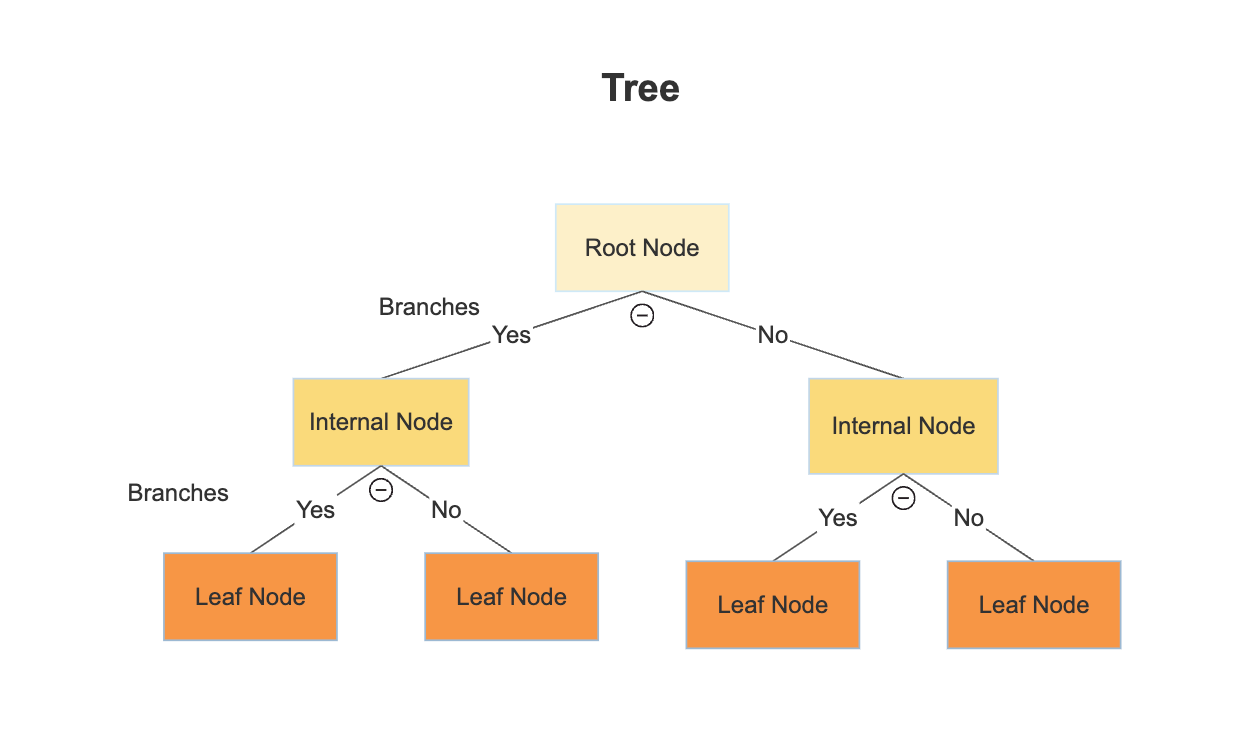




Important Terms for Decision Tree
#  Root Node: It represents the entire dataset, which further gets divided into two or more homogeneous sets.
#  Splitting: It is a process of dividing a node into two or more sub-nodes.
#  Decision Node: When a sub-node splits into further sub-nodes, then it is called the decision node.
#  Leaf/Terminal Node: Nodes do not split is called Leaf or Terminal node.
#  Pruning: When we remove sub-nodes of a decision node, this process is called pruning. You can say the opposite process of splitting.
#  Information Gain: The information gain is based on the decrease in entropy after a dataset is split on an attribute. Constructing a decision tree is all about finding attribute that returns the highest information gain (i.e., the most homogeneous branches).
#  Entropy: A decision tree algorithm always tries to maximize Information Gain. The information gain is based on the decrease in entropy after a dataset is split on an attribute. Constructing a decision tree is all about finding attribute that returns the highest information gain (i.e., the most homogeneous branches).
#  Gini Index: Gini index says, if we select two items from a population at random then they must be of the same class and probability for this is 1 if the population is pure.



In [ ]:
import math

In [ ]:
# Example Dataset
# Let's say we have a dataset with two classes, A and B
# Suppose in a dataset of 10 elements, 4 are of class A and 6 are of class B

# Number of elements in each class
n_A = 40
n_B = 60
total = n_A + n_B


In [ ]:
p_A = n_A/total
p_B = n_B/total

print('Proportion of A:' , p_A)
print('Proportion of B: ' ,p_B)


Proportion of A: 0.4
Proportion of B:  0.6


In [ ]:
# Entropy Calculate
# Entropy is a measure of uncertainty
entropy = -p_A * math.log2(p_A) - p_B * math.log2(p_B)
print("Entropy: " , entropy)

Entropy:  0.9709505944546686


In [ ]:
 #gini impurity
# Gini impurity is a measure of misclassification
gini = 1 - p_A**2 - p_B**2
print("Gini Impurity : " , gini)

Gini Impurity :  0.48


In [ ]:
# Information Gain
# Assuming a split on some feature divides the dataset into two subsets
# Subset 1: 2 elements of A, 3 of B
# Subset 2: 2 elements of A, 3 of B
# Entropy and size for each subset
n_1_A , n_1_B = 2,3
n_2_A , n_2_B = 2,3
p_1_A = n_1_A/(n_1_A + n_1_B)
p_1_B = n_1_B/(n_1_A + n_1_B)
entropy_1 = -p_1_A * math.log2(p_1_A) - p_1_B * math.log2(p_1_B)  if p_1_A and p_1_B else 0
p_2_A = n_2_A / (n_2_A + n_2_B)
p_2_B = n_2_B / (n_2_A + n_2_B)
entropy_2 = -p_2_A * math.log2(p_2_A) - p_2_B * math.log2(p_2_B) if p_2_A and p_2_B else 0
# Calculating information gain
info_gain = entropy - ((n_1_A + n_1_B) / total * entropy_1 + (n_2_A + n_2_B) / total * entropy_2)
print("Information Gain: ", info_gain)


Information Gain:  0.8738555350092017



Based on our example dataset with two classes (A and B), we have calculated the following values:

Entropy: The calculated entropy of the dataset is approximately 0.971. This value indicates a moderate level of disorder in the dataset, considering that it's not very close to 0 (which would mean no disorder) and not at its maximum (which would mean complete disorder for a binary classification).

Gini Impurity: The Gini impurity for the dataset is 0.48. This value, being less than 0.5, suggests some level of purity in the dataset but still indicates a mix of classes A and B.

Information Gain: The information gain from the chosen split is 0.0. This result implies that the split did not reduce the entropy or disorder of the dataset. In other words, the split did not add any additional information that could help distinguish between classes A and B more effectively than before.

These metrics provide insight into the nature of the dataset and the effectiveness of potential splits when constructing a decision tree. In practical applications, you would use these calculations to choose the best feature and split at each node in the tree to maximize the purity of the subsets created.

#  Decision Tree Example in Python

# Decision Tree Classifier


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


In [ ]:
# df.drop('deck' , axis = 1,inplace = True)
imputer = SimpleImputer(strategy='median')
df[['age','fare']] = imputer.fit_transform(df[['age' ,'fare']])
imputer = SimpleImputer (strategy="most_frequent")
df[['embark_town' , 'embarked']] = imputer.fit_transform(df[['embark_town' , 'embarked']])


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include=['category' , 'object']):
  df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(['survived' , 'alive'], axis=1)
y = df['survived']
X_train , X_test , y_train , y_test =train_test_split(X,y,train_size=0.8 , random_state=42)

[[83 22]
 [19 55]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       105
           1       0.71      0.74      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179



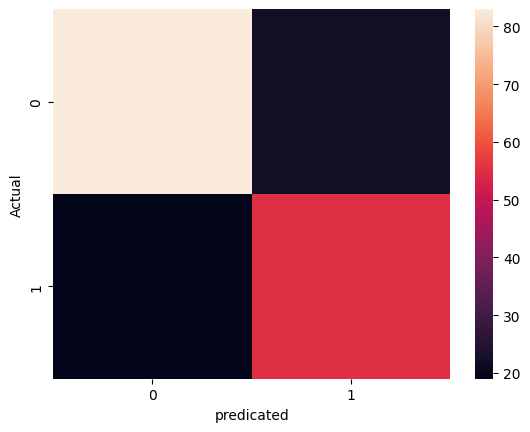

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred))
plt.xlabel('predicated')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.tree import export_graphviz
import os

# Create the directory if it doesn't exist
os.makedirs('./saved_models/', exist_ok=True)

export_graphviz(model, out_file='./saved_models/03_Decision_Tree.dot', feature_names=X.columns, filled=True, rounded=True)

# Decision Tree  Rgressor

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [ ]:
df = sns.load_dataset('tips')

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [ ]:
X = df.drop('tip' , axis = 1)
y = df['tip']

In [ ]:
le = LabelEncoder()
for col in X.columns:
  if X[col].dtype == 'object' or X[col].dtype == 'category':
    X[col] = le.fit_transform(X[col])

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.8, random_state=42)

In [ ]:
model = DecisionTreeRegressor()
model.fit(X_train , y_train)
y_pred=model.predict(X_test)
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test,y_pred))

1.2538367346938777
0.8563265306122451


In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(model, out_file='./saved_models/03_Decision_Tree.dot', feature_names=X.columns, filled=True, rounded=True)